<a href="https://colab.research.google.com/github/mbgarba/Power-comsumption-project/blob/main/Power_comsumption_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
ENERGY_DATAFILE = "energy_data.csv"
energy_raw = pd.read_csv(ENERGY_DATAFILE)
print(energy_raw.shape)
energy_raw.head()

(46608, 173)


,Time,Energy_Meter_1,Energy_Meter_2,Energy_Meter_3,Energy_Meter_4,Energy_Meter_5,Energy_Meter_6,Energy_Meter_7,Energy_Meter_8,Energy_Meter_9,...,Energy_Meter_163,Energy_Meter_164,Energy_Meter_165,Energy_Meter_166,Energy_Meter_167,Energy_Meter_168,Energy_Meter_169,Energy_Meter_170,Energy_Meter_171,Energy_Meter_172
0,2022-05-05 12:00:00,0.068,NaN,0.034,0.038,0.000,NaN,NaN,NaN,NaN,...,NaN,0.004,0.0,NaN,NaN,NaN,0.395,NaN,NaN,0.008
1,2022-05-05 12:15:00,0.070,NaN,0.044,0.062,0.006,NaN,NaN,NaN,NaN,...,NaN,0.003,0.0,NaN,NaN,NaN,0.316,NaN,NaN,0.056
2,2022-05-05 12:30:00,0.122,NaN,0.037,0.045,0.000,NaN,NaN,NaN,NaN,...,NaN,0.004,0.0,NaN,NaN,NaN,0.264,NaN,NaN,0.033
3,2022-05-05 12:45:00,0.132,NaN,0.015,0.039,0.000,NaN,NaN,NaN,NaN,...,NaN,0.004,0.0,NaN,NaN,NaN,0.139,NaN,NaN,0.062
4,2022-05-05 13:00:00,0.125,NaN,0.015,0.040,0.032,NaN,NaN,NaN,NaN,...,NaN,0.004,0.0,NaN,NaN,NaN,0.138,NaN,NaN,0.024


In [3]:
# Data Types
energy_raw.dtypes
energy_raw.Time = pd.to_datetime(energy_raw.Time)
energy_raw.dtypes

,0
Time,datetime64[ns]
Energy_Meter_1,float64
Energy_Meter_2,float64
Energy_Meter_3,float64
Energy_Meter_4,float64
...,...
Energy_Meter_168,float64
Energy_Meter_169,float64
Energy_Meter_170,float64
Energy_Meter_171,float64


In [4]:
# Summary statistics
summary_statistics = energy_raw.describe()
summary_statistics

,Time,Energy_Meter_1,Energy_Meter_2,Energy_Meter_3,Energy_Meter_4,Energy_Meter_5,Energy_Meter_6,Energy_Meter_7,Energy_Meter_8,Energy_Meter_9,...,Energy_Meter_163,Energy_Meter_164,Energy_Meter_165,Energy_Meter_166,Energy_Meter_167,Energy_Meter_168,Energy_Meter_169,Energy_Meter_170,Energy_Meter_171,Energy_Meter_172
count,46608,41822.000000,41748.000000,31617.000000,40510.000000,39516.000000,33408.000000,9938.000000,41731.000000,41713.000000,...,40200.000000,41774.00000,39072.000000,28118.000000,16196.000000,33939.000000,23845.000000,29537.000000,27170.000000,40864.000000
mean,2023-01-03 05:52:30,0.092643,0.062613,0.116356,0.045887,0.002955,0.069740,0.024806,0.121322,0.092286,...,0.054436,0.00387,0.006162,0.087815,0.025371,0.540594,0.157338,0.273103,0.153591,0.086442
min,2022-05-05 12:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.004000,0.000000,0.017000,0.000000,0.000000,0.000000
25%,2022-09-03 20:56:15,0.038000,0.028000,0.044000,0.013000,0.000000,0.000000,0.007000,0.027000,0.051000,...,0.007000,0.00300,0.000000,0.006000,0.019000,0.312000,0.081000,0.142000,0.056000,0.029000
50%,2023-01-03 05:52:30,0.063000,0.046000,0.079000,0.032000,0.000000,0.000000,0.014000,0.095000,0.072000,...,0.008000,0.00400,0.000000,0.007000,0.022000,0.480000,0.114000,0.164000,0.095000,0.043000
75%,2023-05-04 14:48:45,0.103000,0.073000,0.105000,0.045000,0.000000,0.000000,0.021000,0.155000,0.098000,...,0.070250,0.00400,0.000000,0.013000,0.024000,0.735000,0.175000,0.371000,0.144000,0.067000
max,2023-09-02 23:45:00,1.513000,0.962000,1.593000,1.738000,1.032000,1.594000,0.979000,1.412000,0.772000,...,0.509000,0.05000,0.669000,1.530000,0.600000,1.900000,0.995000,2.136000,1.803000,1.609000
std,NaN,0.104881,0.065718,0.143975,0.102041,0.014699,0.286786,0.060112,0.140283,0.087209,...,0.076120,0.00159,0.023565,0.195815,0.023271,0.287114,0.124936,0.199749,0.176724,0.140246


In [5]:
full_date_range = pd.date_range(start="2022-05-05 12:00:00", end = "2023-09-02 23:45:00", freq="15min")

assert (full_date_range == energy_raw.Time).all()

<Axes: xlabel='count', ylabel='Count'>

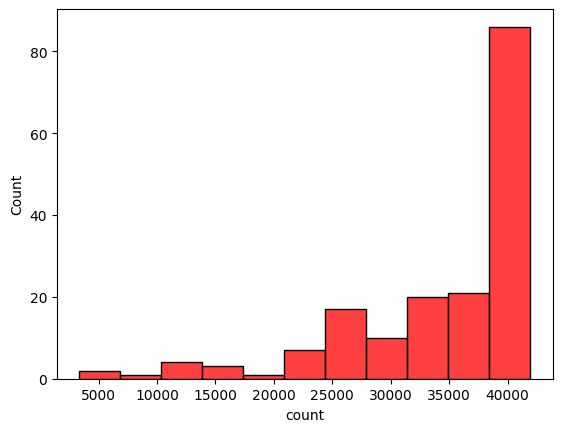

In [8]:
sns.histplot(summary_statistics.iloc[0, 1:], color="red")


In [9]:
energy_raw.duplicated().sum()

0

In [10]:
energy_raw = energy_raw.set_index("Time")
energy_raw.head()

,Energy_Meter_1,Energy_Meter_2,Energy_Meter_3,Energy_Meter_4,Energy_Meter_5,Energy_Meter_6,Energy_Meter_7,Energy_Meter_8,Energy_Meter_9,Energy_Meter_10,...,Energy_Meter_163,Energy_Meter_164,Energy_Meter_165,Energy_Meter_166,Energy_Meter_167,Energy_Meter_168,Energy_Meter_169,Energy_Meter_170,Energy_Meter_171,Energy_Meter_172
Time,,,,,,,,,,,,,,,,,,,,,
2022-05-05 12:00:00,0.068,NaN,0.034,0.038,0.000,NaN,NaN,NaN,NaN,0.007,...,NaN,0.004,0.0,NaN,NaN,NaN,0.395,NaN,NaN,0.008
2022-05-05 12:15:00,0.070,NaN,0.044,0.062,0.006,NaN,NaN,NaN,NaN,0.030,...,NaN,0.003,0.0,NaN,NaN,NaN,0.316,NaN,NaN,0.056
2022-05-05 12:30:00,0.122,NaN,0.037,0.045,0.000,NaN,NaN,NaN,NaN,0.003,...,NaN,0.004,0.0,NaN,NaN,NaN,0.264,NaN,NaN,0.033
2022-05-05 12:45:00,0.132,NaN,0.015,0.039,0.000,NaN,NaN,NaN,NaN,0.022,...,NaN,0.004,0.0,NaN,NaN,NaN,0.139,NaN,NaN,0.062
2022-05-05 13:00:00,0.125,NaN,0.015,0.040,0.032,NaN,NaN,NaN,NaN,0.016,...,NaN,0.004,0.0,NaN,NaN,NaN,0.138,NaN,NaN,0.024


In [11]:
energy_raw.isna().sum().sum()/energy_raw.size

0.2512643802042169

<Axes: ylabel='Count'>

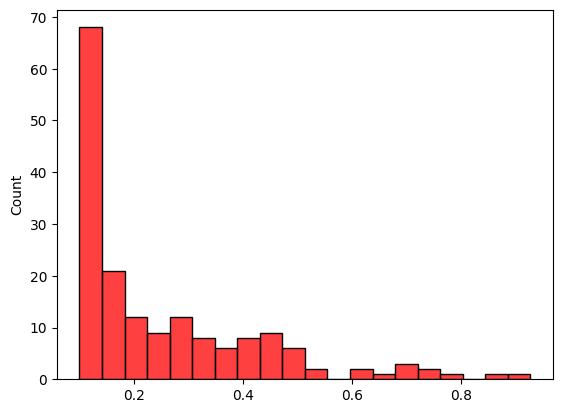

In [12]:
perc_nan_by_device = energy_raw.isna().sum()/len(energy_raw)

sns.histplot(perc_nan_by_device, bins=20, color="red")

In [13]:
perc_nan_by_device.sort_values(ascending=True)

,0
Energy_Meter_140,0.100154
Energy_Meter_91,0.102300
Energy_Meter_132,0.102321
Energy_Meter_17,0.102364
Energy_Meter_125,0.102493
...,...
Energy_Meter_97,0.734359
Energy_Meter_93,0.748884
Energy_Meter_7,0.786775
Energy_Meter_46,0.860990


Energy_Meter_38
Energy_Meter_46
Energy_Meter_7
Energy_Meter_93
Energy_Meter_97


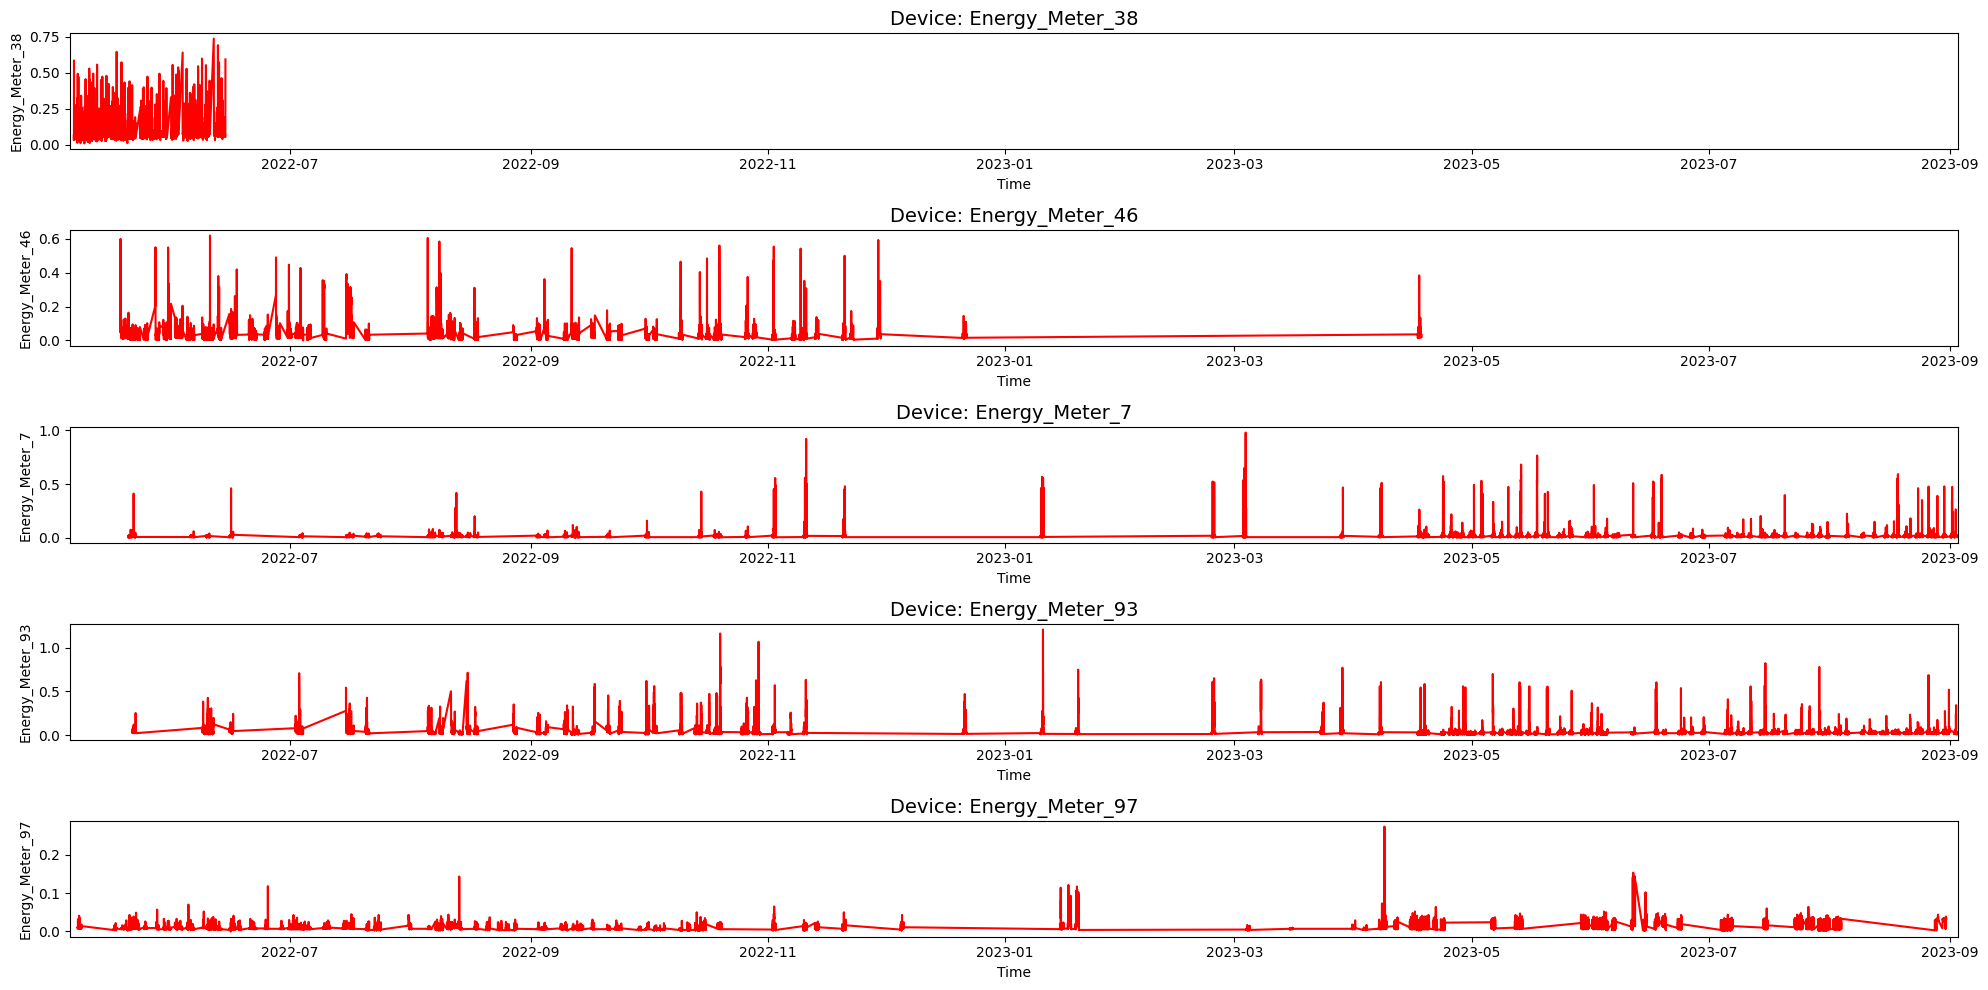

In [14]:
# Which are the devices with the highest % of missing values?
low_value_meters = perc_nan_by_device.sort_values(ascending=False).index[0:5]
low_value_meters

fig, ax = plt.subplots(nrows=5, figsize=(20, 10))

for i, column in enumerate(low_value_meters):
    print(column)
    plot1 = sns.lineplot(data=energy_raw[column], ax=ax[i], color="red")
    plot1.set_xlim(energy_raw.index.min(), energy_raw.index.max())
    ax[i].set_title(f"Device: {column}", fontsize=14)  # Optional: Add a title for each subplot
plt.tight_layout()


Energy_Meter_140
Energy_Meter_91
Energy_Meter_132
Energy_Meter_17
Energy_Meter_125


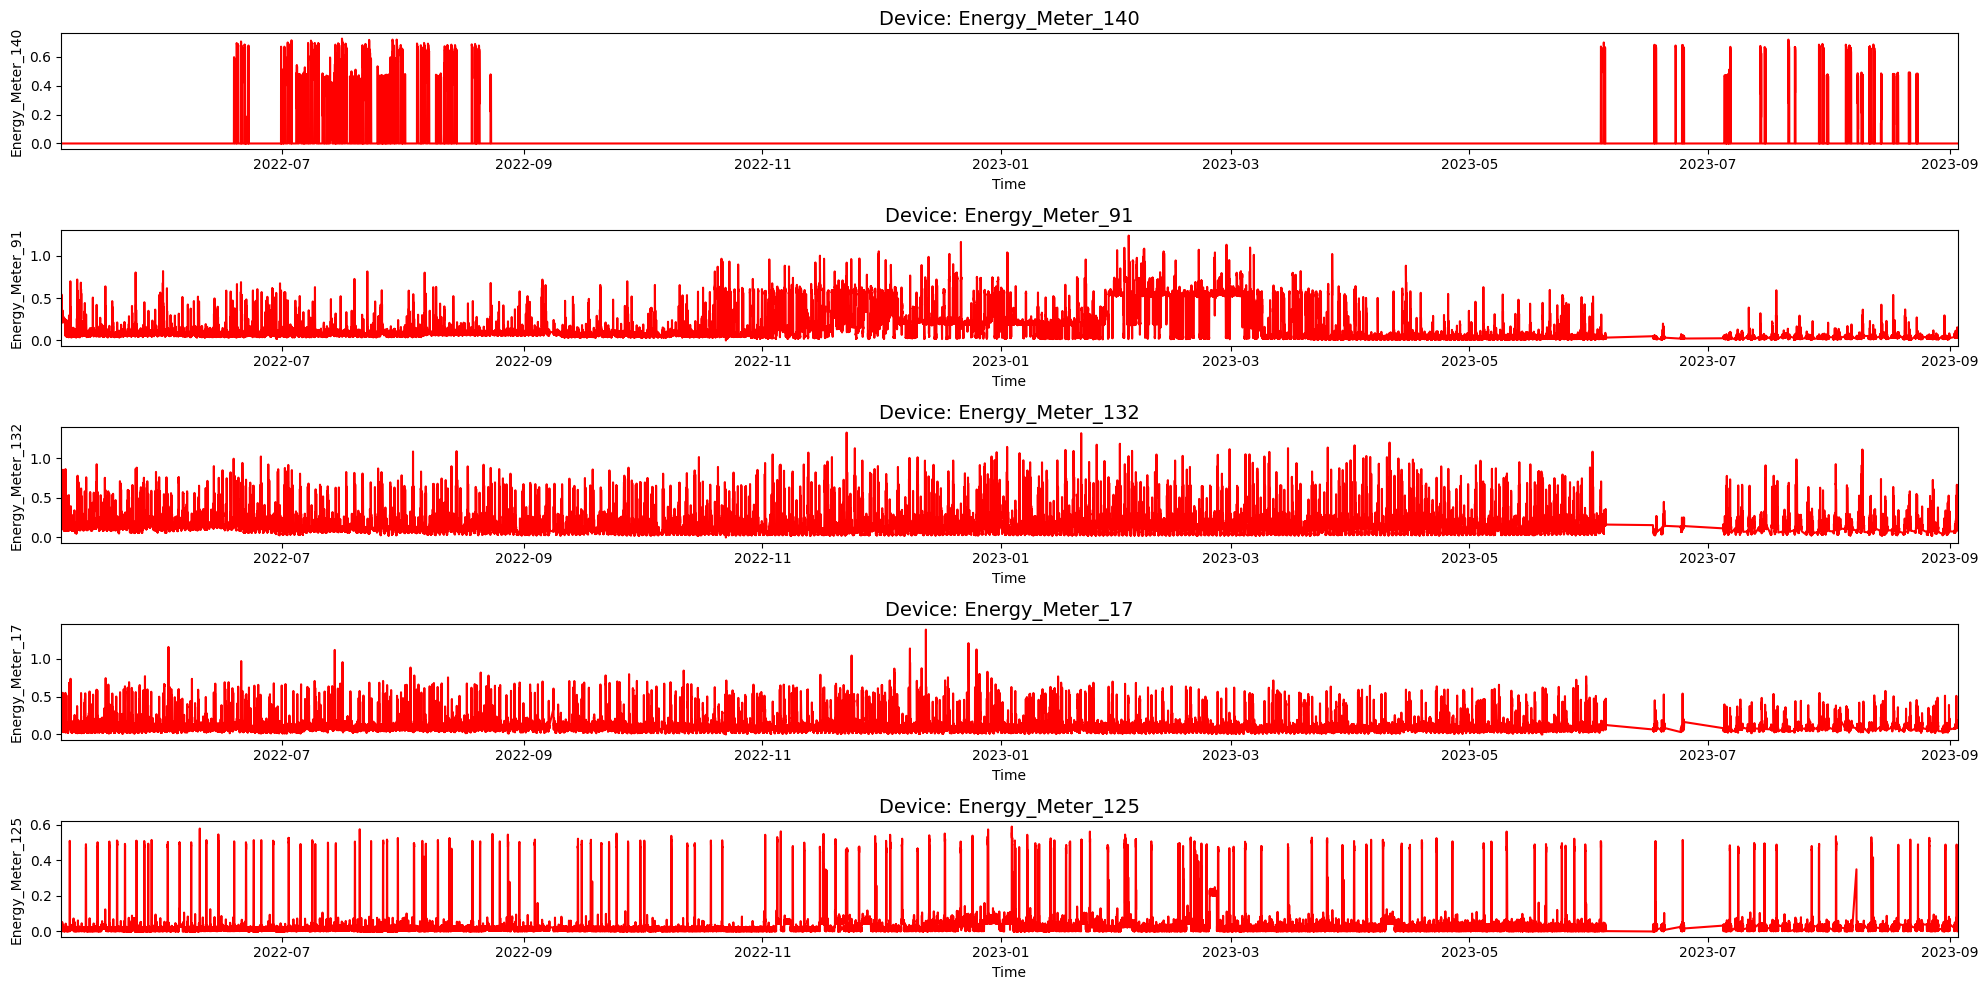

In [15]:
# Which are the devices with the lowest % of missing values?
low_value_meters = perc_nan_by_device.sort_values(ascending=True).index[0:5]
low_value_meters

fig, ax = plt.subplots(nrows=5, figsize=(20, 10))

for i, column in enumerate(low_value_meters):
    print(column)
    plot1 = sns.lineplot(data=energy_raw[column], ax=ax[i], color="red")
    plot1.set_xlim(energy_raw.index.min(), energy_raw.index.max())
    ax[i].set_title(f"Device: {column}", fontsize=14)  # Optional: Add a title for each subplot
plt.tight_layout()


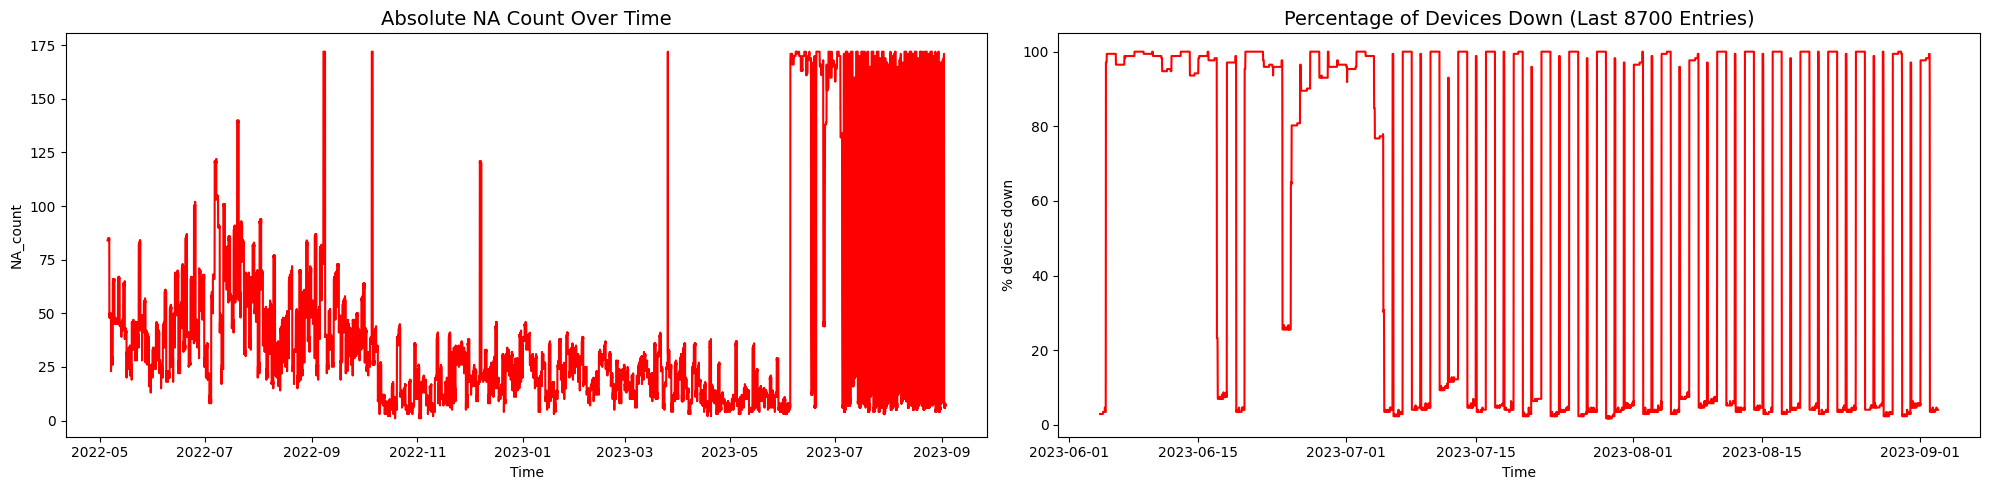

In [16]:
nan_by_date = energy_raw.isna().sum(axis=1)
nan_by_date = nan_by_date.rename("NA_count").reset_index()
perc_nan_by_date = nan_by_date.copy()
perc_nan_by_date.NA_count = 100 * perc_nan_by_date.NA_count / 172

fig, ax = plt.subplots(ncols=2, figsize=(20, 5))

# Plot 1: Absolute number of missing values
sns.lineplot(data=nan_by_date, x="Time", y="NA_count", ax=ax[0], color="red")
ax[0].set_title("Absolute NA Count Over Time", fontsize=14)

# Plot 2: Percentage of devices down
sns.lineplot(data=perc_nan_by_date[-8700:], x="Time", y="NA_count", ax=ax[1], color="red")
ax[1].set_ylabel("% devices down")
ax[1].set_title("Percentage of Devices Down (Last 8700 Entries)", fontsize=14)

plt.tight_layout()


<Axes: >

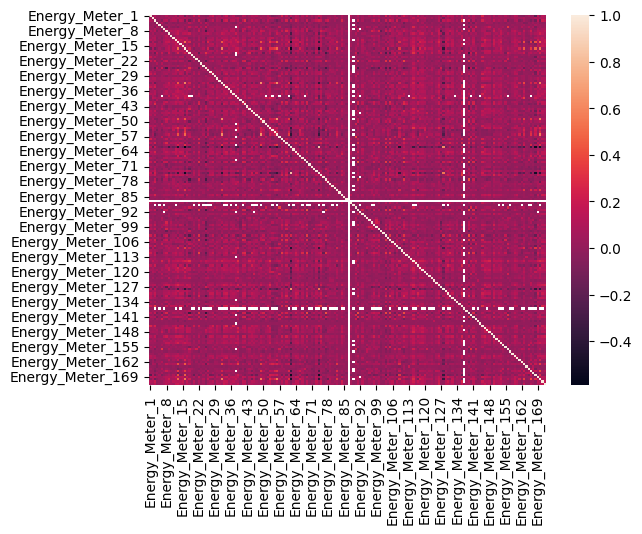

In [17]:
corr_mat = energy_raw.corr()
sns.heatmap(corr_mat)

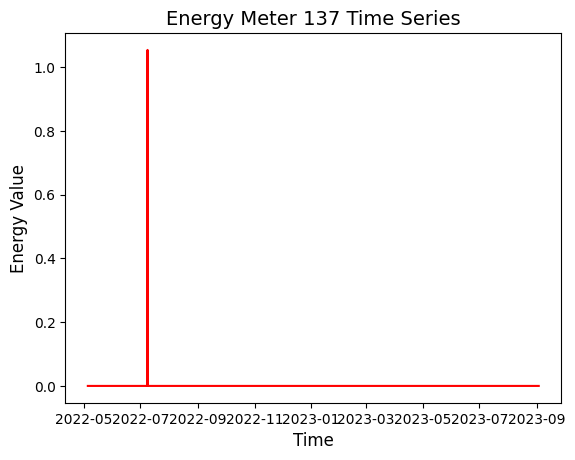

In [18]:
sns.lineplot(data=energy_raw["Energy_Meter_137"], color="red")
plt.title("Energy Meter 137 Time Series", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Energy Value", fontsize=12)
plt.show()


<Axes: >

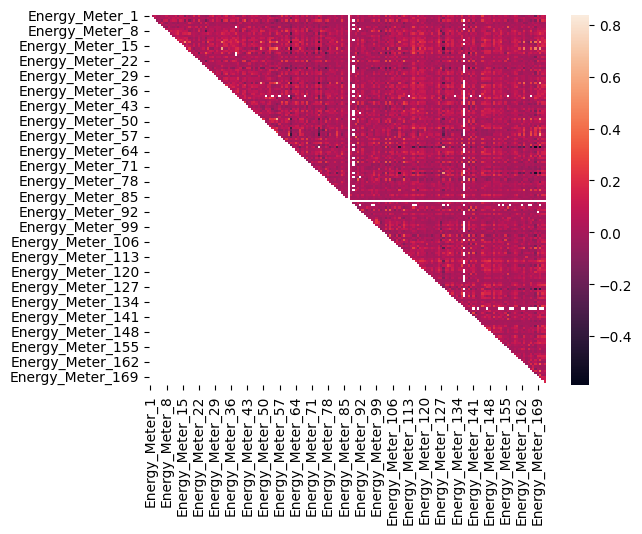

In [19]:
il = np.tril_indices(172)

triang_corr = corr_mat.copy().to_numpy()
triang_corr[il] = np.nan

triang_corr = pd.DataFrame(triang_corr, columns = corr_mat.columns, index=corr_mat.index)
sns.heatmap(triang_corr)

In [20]:
xx =  triang_corr[(triang_corr>0.5) & (triang_corr<1) | (triang_corr<=-0.5)]
for i in xx: #row
    for j, cell in enumerate(xx[i]): #col
        if np.isnan(cell) == False:
            print(i, xx.columns[j], cell)

Energy_Meter_16 Energy_Meter_13 0.5198573813342061
Energy_Meter_32 Energy_Meter_16 0.589572270846768
Energy_Meter_49 Energy_Meter_32 0.6398352760639234
Energy_Meter_56 Energy_Meter_16 0.5089606314442484
Energy_Meter_56 Energy_Meter_32 0.6232417416634765
Energy_Meter_56 Energy_Meter_49 0.6574558177598908
Energy_Meter_62 Energy_Meter_16 -0.5869369063441462
Energy_Meter_74 Energy_Meter_16 -0.5203511008044513
Energy_Meter_74 Energy_Meter_62 0.8366684465322936
Energy_Meter_128 Energy_Meter_62 0.6353831199427828
Energy_Meter_128 Energy_Meter_74 0.5415537217782208
Energy_Meter_168 Energy_Meter_62 -0.5369415090488009
Energy_Meter_168 Energy_Meter_74 -0.5028392784284538
Energy_Meter_170 Energy_Meter_16 0.5510489362950091
Energy_Meter_170 Energy_Meter_32 0.584191210181062
Energy_Meter_170 Energy_Meter_49 0.5702835764927463
Energy_Meter_170 Energy_Meter_56 0.5711019602159457


<Axes: xlabel='Time', ylabel='Energy_Meter_49'>

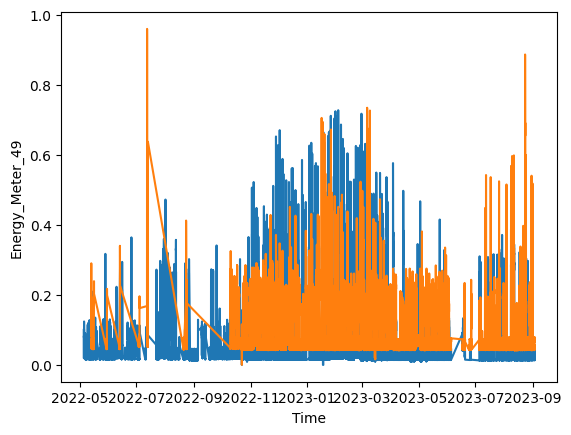

In [21]:
sns.lineplot(energy_raw["Energy_Meter_49"])
sns.lineplot(energy_raw["Energy_Meter_32"])

In [22]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

In [23]:
df_scaled = std_scaler.fit_transform(energy_raw.to_numpy())
energy_df = pd.DataFrame(df_scaled, columns=energy_raw.columns, index=energy_raw.index)
energy_df.head(3)

,Energy_Meter_1,Energy_Meter_2,Energy_Meter_3,Energy_Meter_4,Energy_Meter_5,Energy_Meter_6,Energy_Meter_7,Energy_Meter_8,Energy_Meter_9,Energy_Meter_10,...,Energy_Meter_163,Energy_Meter_164,Energy_Meter_165,Energy_Meter_166,Energy_Meter_167,Energy_Meter_168,Energy_Meter_169,Energy_Meter_170,Energy_Meter_171,Energy_Meter_172
Time,,,,,,,,,,,,,,,,,,,,,
2022-05-05 12:00:00,-0.234968,NaN,-0.572023,-0.077290,-0.201075,NaN,NaN,NaN,NaN,-0.334447,...,NaN,0.082047,-0.261512,NaN,NaN,NaN,1.902315,NaN,NaN,-0.559324
2022-05-05 12:15:00,-0.215898,NaN,-0.502566,0.157913,0.207132,NaN,NaN,NaN,NaN,0.528066,...,NaN,-0.546836,-0.261512,NaN,NaN,NaN,1.269976,NaN,NaN,-0.217065
2022-05-05 12:30:00,0.279906,NaN,-0.551186,-0.008689,-0.201075,NaN,NaN,NaN,NaN,-0.484450,...,NaN,0.082047,-0.261512,NaN,NaN,NaN,0.853753,NaN,NaN,-0.381064


In [24]:
energy_df = energy_df.reset_index()
energy_df.head(2)

,Time,Energy_Meter_1,Energy_Meter_2,Energy_Meter_3,Energy_Meter_4,Energy_Meter_5,Energy_Meter_6,Energy_Meter_7,Energy_Meter_8,Energy_Meter_9,...,Energy_Meter_163,Energy_Meter_164,Energy_Meter_165,Energy_Meter_166,Energy_Meter_167,Energy_Meter_168,Energy_Meter_169,Energy_Meter_170,Energy_Meter_171,Energy_Meter_172
0,2022-05-05 12:00:00,-0.234968,NaN,-0.572023,-0.077290,-0.201075,NaN,NaN,NaN,NaN,...,NaN,0.082047,-0.261512,NaN,NaN,NaN,1.902315,NaN,NaN,-0.559324
1,2022-05-05 12:15:00,-0.215898,NaN,-0.502566,0.157913,0.207132,NaN,NaN,NaN,NaN,...,NaN,-0.546836,-0.261512,NaN,NaN,NaN,1.269976,NaN,NaN,-0.217065


In [25]:
energy_df["monthofyear"] = [str(n).zfill(2)+"-"+m for n, m in zip(energy_df.Time.dt.month, energy_df.Time.dt.month_name())]
energy_df["month"] = energy_df.Time.dt.to_period("M")
energy_df["dayofweek"] = [str(n).zfill(2)+"-"+m for n, m in zip(energy_df.Time.dt.dayofweek, energy_df.Time.dt.day_name())] # 0:Monday, 6:Sunday
energy_df["day"] = energy_df.Time.dt.to_period("D")
energy_df["hour"] = energy_df.Time.dt.to_period("h")
energy_df.head(3)

,Time,Energy_Meter_1,Energy_Meter_2,Energy_Meter_3,Energy_Meter_4,Energy_Meter_5,Energy_Meter_6,Energy_Meter_7,Energy_Meter_8,Energy_Meter_9,...,Energy_Meter_168,Energy_Meter_169,Energy_Meter_170,Energy_Meter_171,Energy_Meter_172,monthofyear,month,dayofweek,day,hour
0,2022-05-05 12:00:00,-0.234968,NaN,-0.572023,-0.077290,-0.201075,NaN,NaN,NaN,NaN,...,NaN,1.902315,NaN,NaN,-0.559324,05-May,2022-05,03-Thursday,2022-05-05,2022-05-05 12:00
1,2022-05-05 12:15:00,-0.215898,NaN,-0.502566,0.157913,0.207132,NaN,NaN,NaN,NaN,...,NaN,1.269976,NaN,NaN,-0.217065,05-May,2022-05,03-Thursday,2022-05-05,2022-05-05 12:00
2,2022-05-05 12:30:00,0.279906,NaN,-0.551186,-0.008689,-0.201075,NaN,NaN,NaN,NaN,...,NaN,0.853753,NaN,NaN,-0.381064,05-May,2022-05,03-Thursday,2022-05-05,2022-05-05 12:00


<Axes: xlabel='monthofyear'>

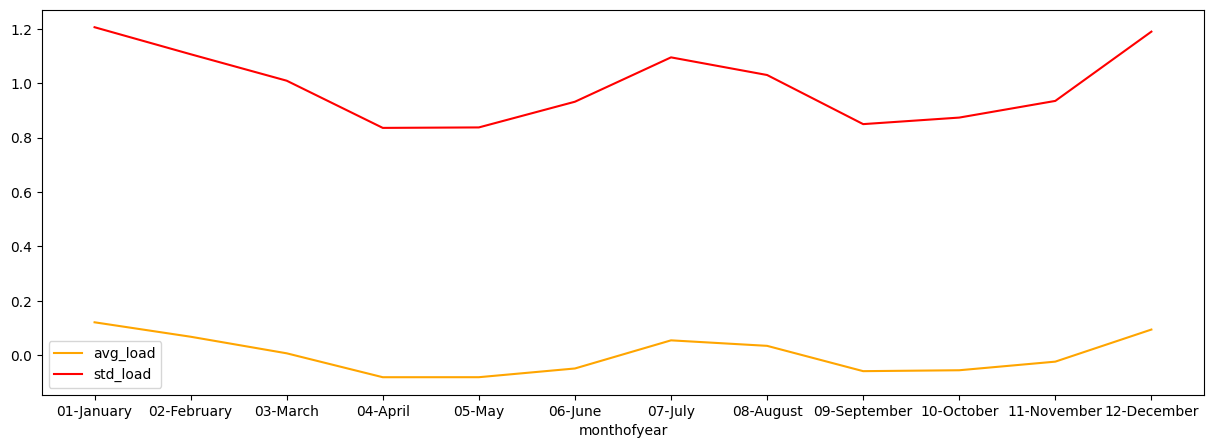

In [27]:
cols =[i for i in energy_raw.columns if i.startswith("Energy_")]
cols.append("monthofyear")

_monthly = energy_df[cols].melt(id_vars="monthofyear")
monthly = _monthly.rename(columns={"value":"avg_load"})[["monthofyear", "avg_load"]]
avg_monthly = monthly.groupby("monthofyear").mean()

std_monthly = _monthly.rename(columns = {"value":"std_load"})[["monthofyear", "std_load"]].groupby("monthofyear").std()
fig, ax = plt.subplots(figsize=(15,5))
av_m = sns.lineplot(avg_monthly, palette=["orange"])
sns.lineplot(std_monthly, palette=["red"])

<ipython-input-29-6021e9d6877d>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=monthly_usage, x="month", y="kWh", ax=ax[0], palette=palette)
<ipython-input-29-6021e9d6877d>:13: UserWarning: 
The palette list has fewer values (1) than needed (17) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=monthly_usage, x="month", y="kWh", ax=ax[0], palette=palette)
<ipython-input-29-6021e9d6877d>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=monthly_usage[monthly_usage.kWh < 2500], x="month", y="kWh", ax=ax[1], palette=palette)
<ipython-input-29-6021e9d6877d>:19: UserWarning: 
The palette list has fewer values (1) than needed (17) and will cycle, which ma

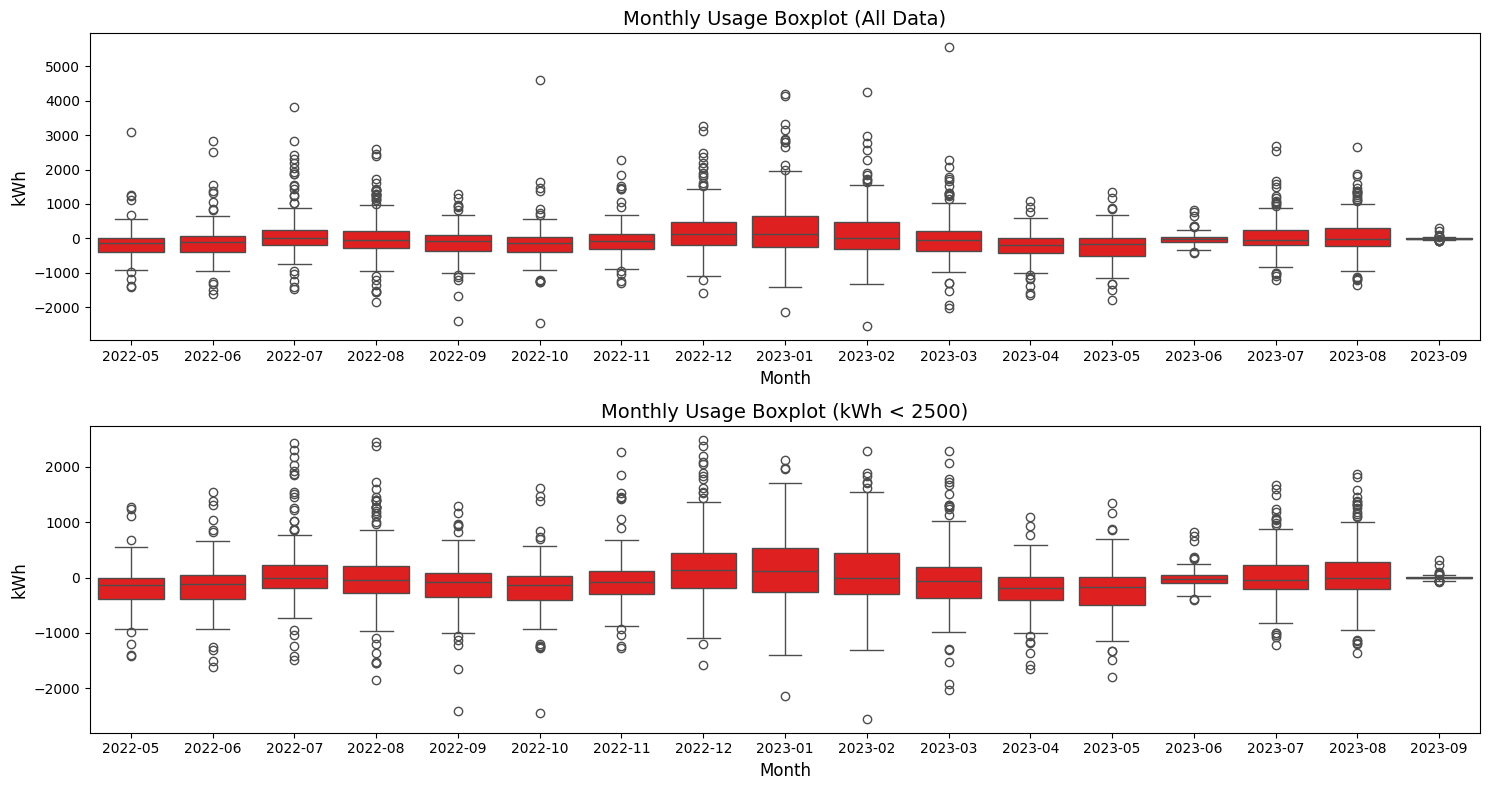

In [29]:
cols = [i for i in energy_df.columns if i.startswith("Energy_")]
cols.append("month")

monthly_usage = energy_df[cols].groupby("month").sum().reset_index()
monthly_usage = monthly_usage.melt(id_vars="month").rename(columns={"variable": "meter_id", "value": "kWh"})  # .set_index("month")

# Define a red palette for the plots
palette = sns.color_palette(["red"])

fig, ax = plt.subplots(figsize=(15, 8), nrows=2)

# Boxplot for all monthly usage
sns.boxplot(data=monthly_usage, x="month", y="kWh", ax=ax[0], palette=palette)
ax[0].set_title("Monthly Usage Boxplot (All Data)", fontsize=14)
ax[0].set_xlabel("Month", fontsize=12)
ax[0].set_ylabel("kWh", fontsize=12)

# Boxplot for monthly usage with kWh < 2500
sns.boxplot(data=monthly_usage[monthly_usage.kWh < 2500], x="month", y="kWh", ax=ax[1], palette=palette)
ax[1].set_title("Monthly Usage Boxplot (kWh < 2500)", fontsize=14)
ax[1].set_xlabel("Month", fontsize=12)
ax[1].set_ylabel("kWh", fontsize=12)

plt.tight_layout()
plt.show()


<ipython-input-30-ced0b4bbee33>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=monthly_usage, x="dayofweek", y="kWh", ax=ax[0], palette=palette)
<ipython-input-30-ced0b4bbee33>:14: UserWarning: 
The palette list has fewer values (1) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=monthly_usage, x="dayofweek", y="kWh", ax=ax[0], palette=palette)
<ipython-input-30-ced0b4bbee33>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=monthly_usage[monthly_usage.kWh < 1200], x="dayofweek", y="kWh", ax=ax[1], palette=palette)
<ipython-input-30-ced0b4bbee33>:20: UserWarning: 
The palette list has fewer values (1) than needed (7) and will cycle

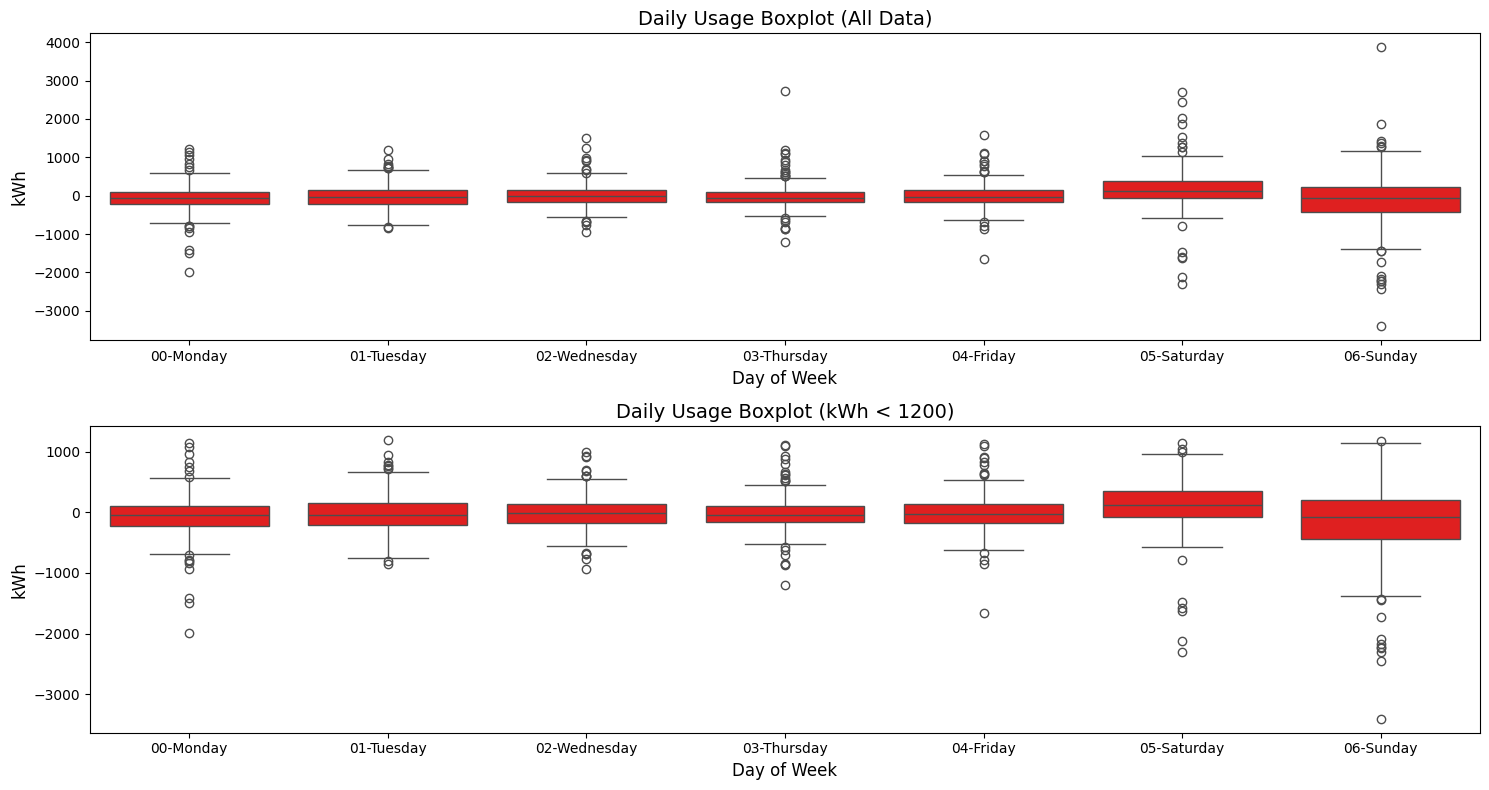

In [30]:
cols = [i for i in energy_raw.columns if i.startswith("Energy_")]
cols.append("dayofweek")

# Grouping by day of the week and reshaping
monthly_usage = energy_df[cols].groupby("dayofweek").sum().reset_index()
monthly_usage = monthly_usage.melt(id_vars="dayofweek").rename(columns={"variable": "meter_id", "value": "kWh"})

# Define a red palette for the plots
palette = sns.color_palette(["red"])

fig, ax = plt.subplots(figsize=(15, 8), nrows=2)

# Boxplot for all daily usage
sns.boxplot(data=monthly_usage, x="dayofweek", y="kWh", ax=ax[0], palette=palette)
ax[0].set_title("Daily Usage Boxplot (All Data)", fontsize=14)
ax[0].set_xlabel("Day of Week", fontsize=12)
ax[0].set_ylabel("kWh", fontsize=12)

# Boxplot for daily usage with kWh < 1200
sns.boxplot(data=monthly_usage[monthly_usage.kWh < 1200], x="dayofweek", y="kWh", ax=ax[1], palette=palette)
ax[1].set_title("Daily Usage Boxplot (kWh < 1200)", fontsize=14)
ax[1].set_xlabel("Day of Week", fontsize=12)
ax[1].set_ylabel("kWh", fontsize=12)

plt.tight_layout()
plt.show()
